In [1]:
!pip install -q python-igraph scikit-learn ripser persim openTSNE

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 841.3/841.3 kB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.6/48.6 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 35.1 MB/s eta 0:00:00


In [2]:
import torch
from torch.utils.data import Subset
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt

# Define the transformation pipeline:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: (x > 0.5).float()),  # Binarize the image
    transforms.Lambda(lambda x: x.view(-1))           # Flatten into a 784-dim vector
])

# Load the training set (set download=True if running for the first time)
mnist_train = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)

# Get indices for images where the label is 1
indices = (mnist_train.targets == 1).nonzero().squeeze()

# Create a subset containing only the '1's
mnist_train_ones = Subset(mnist_train, indices)

print(f"Total number of '1' images in the training set: {len(mnist_train_ones)}")

# Stack all 784-dim vectors from the filtered dataset
all_vectors = torch.stack([img for img, _ in mnist_train_ones])
unique_vectors = torch.unique(all_vectors, dim=0)

print(f"Total images in mnist_train_ones: {all_vectors.shape[0]}")
print(f"Unique images: {unique_vectors.shape[0]}")

if all_vectors.shape[0] == unique_vectors.shape[0]:
    print("All 784-dimensional vectors are unique.")
else:
    print("There are duplicates in the 784-dimensional vectors.")

vectors_np = unique_vectors.numpy()

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 481kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.40MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.05MB/s]


Total number of '1' images in the training set: 6742
Total images in mnist_train_ones: 6742
Unique images: 6726
There are duplicates in the 784-dimensional vectors.


In [3]:
import numpy as np
from sklearn.neighbors import NearestNeighbors
import igraph as ig

def build_weighted_filtered_knn_graph(X, k, max_distance=6.0):
    """
    Builds an undirected k-NN graph on `unique_vectors` but only keeps edges
    whose Euclidean length ≤ max_distance.  Each edge gets a 'weight' attribute
    equal to its Euclidean distance.

    Parameters
    ----------
    unique_vectors : array-like, shape (n, d)
        Your dataset (can be a numpy array or a torch tensor with .numpy()).
    k : int
        The number of nearest neighbours to consider per point.
    max_distance : float
        The distance threshold for pruning edges.

    Returns
    -------
    g : igraph.Graph
        An undirected graph on n vertices with only the filtered edges, and
        g.es['weight'] giving each edge’s Euclidean length.
    """
    n = X.shape[0]
    print(f"Building weighted filtered k-NN graph for {n} nodes with edge dist ≤ {max_distance}...")

    # find k+1 neighbors (including self)
    nbrs = NearestNeighbors(n_neighbors=k+1).fit(X)
    distances, indices = nbrs.kneighbors(X)

    edge_list = []
    weight_list = []
    for i, (neighbors, dists) in enumerate(zip(indices, distances)):
        # skip the first neighbor (itself)
        for j, dist in zip(neighbors[1:], dists[1:]):
            # only add each edge once (i<j) and only if within threshold
            if dist <= max_distance and i < j:
                edge_list.append((i, j))
                weight_list.append(dist)

    # build igraph and assign weights
    g = ig.Graph(n=n, edges=edge_list, directed=False)
    g.es['weight'] = weight_list

    print(f"Graph built: {n} vertices, {g.ecount()} edges.")
    return g

g_weighted = build_weighted_filtered_knn_graph(vectors_np, k=5, max_distance=6)


Building weighted filtered k-NN graph for 6726 nodes with edge dist ≤ 6...
Graph built: 6726 vertices, 15068 edges.


In [4]:
# find all connected components
components = g_weighted.clusters()    # or g_weighted.components()

# extract the subgraph of the largest one
g_largest = components.giant()

print(f"Largest component has {g_largest.vcount()} vertices and {g_largest.ecount()} edges")


Largest component has 6372 vertices and 15015 edges


<ipython-input-4-facadf845211>:2: DeprecationWarning: Graph.clusters() is deprecated; use Graph.connected_components() instead
  components = g_weighted.clusters()    # or g_weighted.components()


In [43]:
from tqdm import tqdm

# --- OPTION B: precompute full distance matrix once ---
D = np.array(g_largest.distances(weights='weight'))
good_nodes = []

for v in range(g_largest.vcount()):
    first  = set(g_largest.neighbors(v))
    second = set().union(*(g_largest.neighbors(u) for u in first))
    second -= first
    second.discard(v)

    if second and np.all(D[v, list(second)] <= 6.0):
        good_nodes.append(v)

print("\nnodes whose 2nd-degree neighbors are all within 6:", good_nodes)
print(f"Found {len(good_nodes)} nodes")

100%|██████████| 6372/6372 [00:00<00:00, 27300.65it/s]


nodes whose 2nd-degree neighbors are all within 6: [52, 55, 59, 73, 77, 452, 586, 598, 616, 641, 682, 824, 864, 866, 868, 869, 888, 891, 894, 895, 896, 900, 903, 908, 915, 919, 922, 923, 952, 970, 971, 980, 1028, 1030, 1037, 1044, 1045, 1077, 1116, 1167, 1202, 1210, 1213, 1222, 1226, 1227, 1231, 1242, 1243, 1245, 1248, 1250, 1262, 1283, 1300, 1303, 1305, 1308, 1309, 1311, 1312, 1314, 1319, 1320, 1322, 1324, 1325, 1326, 1327, 1329, 1330, 1332, 1339, 1341, 1342, 1349, 1352, 1359, 1417, 1441, 1445, 1490, 1498, 1503, 1509, 1563, 1567, 1568, 1569, 1572, 1573, 1574, 1575, 1576, 1579, 1580, 1583, 1584, 1585, 1586, 1589, 1611, 1614, 1616, 1626, 1638, 1644, 1645, 1647, 1649, 1656, 1663, 1669, 1670, 1694, 1707, 1709, 1712, 1732, 1746, 1747, 1749, 1751, 1759, 1763, 1772, 1782, 1801, 1803, 1808, 1810, 1812, 1813, 1821, 1823, 1845, 1872, 1882, 1883, 1886, 1888, 1897, 1907, 1917, 1921, 1922, 1923, 1926, 1928, 1930, 1933, 1937, 1938, 1945, 1947, 1949, 1950, 1951, 1955, 1956, 1958, 1974, 1979, 1981, 

In [45]:
import numpy as np
from tqdm import tqdm

# precompute weighted shortest-path distances once
# D = np.array(g_largest.distances(weights='weight'))

threshold = 6.0
max_hop    = 5    # how far you want to search before giving up
results    = {k: [] for k in range(2, max_hop+1)}

for v in range(g_largest.vcount()):
    # for each node, try hops = 2, 3, 4, … until either it fails or you hit max_hop
    for k in range(2, max_hop+1):
        # get exactly the k-hop neighbors of v
        neigh_k = g_largest.neighborhood(v, order=k, mindist=k)[0]
        if not neigh_k:
            break

        # check if every one of those is within threshold in the weighted graph
        if np.all(D[v, neigh_k] <= threshold):
            results[k].append(v)
        else:
            break
print('\n')
# results[k] is the list of nodes for which *all* their k-hop neighbors lie within distance ≤ 6
for k in sorted(results):
    print(f"hop={k:>2} → {len(results[k])} nodes")


100%|██████████| 6372/6372 [00:00<00:00, 32135.16it/s]



hop= 2 → 2315 nodes
hop= 3 → 74 nodes
hop= 4 → 2 nodes
hop= 5 → 0 nodes


In [99]:
import numpy as np
import igraph as ig
from numpy.linalg import norm

# — assume you already have:
#    g_largest : igraph.Graph with g_largest.es['weight']
#    results   : dict mapping k -> list of center-vertex IDs

# 1) make a copy to prune
g_pruned = g_largest.copy()
g_pruned.vs['orig_idx'] = list(range(len(vectors_np)))

# 2) accumulate vertices to delete and edges to add
to_delete    = set()
edges_to_add = []   # tuples of (center, outside_node, weight)

for k, centers in results.items():
    for v in centers:
        # get exactly the k-hop neighbors of v (exclude v itself)
        # get k-1 hop neighbors because all those within that range are within distance threshold, neighbors of kth degree are not guaranteed within threshold
        neighs = set(g_largest.neighborhood(v, order=k-1, mindist=1))
        neighs.discard(v)
        if not neighs:
            continue

        # mark for deletion
        to_delete |= neighs

        # for each neighbor n, reroute any edge (n—x) where x∉neighs and x≠v
        for n in neighs:
            for e_idx in g_pruned.incident(n):
                a, b = g_pruned.es[e_idx].tuple
                other = b if a == n else a

                if other not in neighs and other != v:
                    # recompute correct direct distance
                    w_new = norm(vectors_np[v] - vectors_np[other])
                    edges_to_add.append((v, other, w_new))

# 3) add all new “shortcut” edges onto their centers
# for v, other, w in edges_to_add:
#     # if not g_pruned.are_adjacent(v, other):
#         g_pruned.add_edge(v, other, weight=w)

# 4) delete every marked vertex (in descending order to avoid re-indexing issues)
# g_pruned.delete_vertices(sorted(to_delete, reverse=True))

# print(f"Pruned graph: {g_pruned.vcount()} vertices, {g_pruned.ecount()} edges")


In [100]:
# 1) Build a dict of unique new edges → weight (pick the minimum weight if duplicates occur)
edge_dict = {}
for v, other, w in edges_to_add:
    a, b = sorted((v, other))
    edge_dict[(a, b)] = min(w, edge_dict.get((a, b), w))

# 2) Fetch the set of existing undirected edges (as sorted tuples)
existing = set(tuple(sorted(e)) for e in g_pruned.get_edgelist())

# 3) Filter out any that already exist
to_create = [(a, b) for (a, b), w in edge_dict.items() if (a, b) not in existing]
# weights   = [edge_dict[(a, b)] for (a, b) in to_create]

if to_create:
    # 4) Add them all at once
    g_pruned.add_edges(to_create)
    # 5) Assign their weights en masse
    #    Newly added edges are always at the end of g_pruned.es
    start = g_pruned.ecount() - len(to_create)
    g_pruned.es[start:]['weight'] = w_new

In [101]:
# 4) delete every marked vertex (in descending order to avoid re-indexing issues)
g_pruned.delete_vertices(sorted(to_delete, reverse=True))

print(f"Pruned graph: {g_pruned.vcount()} vertices, {g_pruned.ecount()} edges")

Pruned graph: 2386 vertices, 4318 edges


In [102]:
# find all connected components
cl = g_pruned.clusters()   # or g_pruned.components()

# pair up (component_id, vertex_count)
comp_sizes = list(enumerate(cl.sizes()))
# sort descending by vertex_count
comp_sizes.sort(key=lambda x: x[1], reverse=True)

# print top 10
for comp_id, vcount in comp_sizes[:10]:
    verts = cl[comp_id]              # list of vertex IDs in this component
    subg  = g_pruned.subgraph(verts) # induced subgraph
    ecount = subg.ecount()
    print(f"Component {comp_id:2d}: {vcount:5d} vertices, {ecount:5d} edges")


Component  0:  2149 vertices,  4233 edges
Component  1:    13 vertices,    16 edges
Component  9:     9 vertices,     9 edges
Component 20:     6 vertices,     7 edges
Component  5:     4 vertices,     3 edges
Component 100:     4 vertices,     4 edges
Component  3:     3 vertices,     2 edges
Component  4:     3 vertices,     2 edges
Component  6:     3 vertices,     3 edges
Component  8:     3 vertices,     2 edges


<ipython-input-102-0724839ddea5>:2: DeprecationWarning: Graph.clusters() is deprecated; use Graph.connected_components() instead
  cl = g_pruned.clusters()   # or g_pruned.components()


In [103]:
# find all connected components
cl = g_weighted.clusters()   # or g_pruned.components()

# pair up (component_id, vertex_count)
comp_sizes = list(enumerate(cl.sizes()))
# sort descending by vertex_count
comp_sizes.sort(key=lambda x: x[1], reverse=True)

# print top 10
for comp_id, vcount in comp_sizes[:10]:
    verts = cl[comp_id]              # list of vertex IDs in this component
    subg  = g_weighted.subgraph(verts) # induced subgraph
    ecount = subg.ecount()
    print(f"Component {comp_id:2d}: {vcount:5d} vertices, {ecount:5d} edges")


Component  0:  6372 vertices, 15015 edges
Component 264:    10 vertices,    12 edges
Component 120:     4 vertices,     3 edges
Component 221:     4 vertices,     3 edges
Component 84:     3 vertices,     2 edges
Component 134:     3 vertices,     2 edges
Component 159:     3 vertices,     2 edges
Component 167:     3 vertices,     2 edges
Component 192:     3 vertices,     2 edges
Component  3:     2 vertices,     1 edges


<ipython-input-103-93514c6d32b0>:2: DeprecationWarning: Graph.clusters() is deprecated; use Graph.connected_components() instead
  cl = g_weighted.clusters()   # or g_pruned.components()


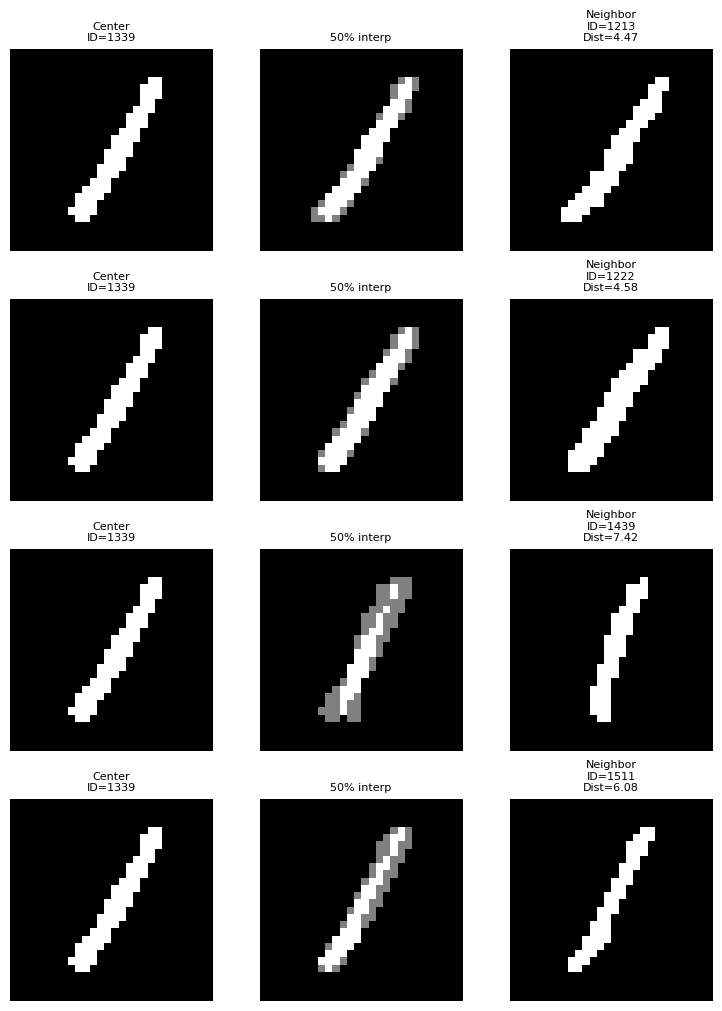

In [104]:
import numpy as np
import random
import matplotlib.pyplot as plt

# Assumes g_pruned, vectors_np, and results are already defined in this session.

# 1) Find the largest component
comp  = g_pruned.connected_components()
giant = comp.giant()
giant_ids = set(giant.vs.indices)

# 2) Identify surviving center nodes
center_nodes = set(v for centers in results.values() for v in centers)
eligible     = list(center_nodes & giant_ids)
if not eligible:
    raise RuntimeError("No pruned-center nodes found in the largest component.")

# 3) Pick one center at random
v = random.choice(eligible)
orig_v = g_pruned.vs[v]['orig_idx']
vec_v  = vectors_np[orig_v]
img_v  = vec_v.reshape(28, 28)

# 4) Get neighbors
neighbors = g_pruned.neighbors(v)
n_neighbors = len(neighbors)
if n_neighbors == 0:
    raise RuntimeError("Chosen center has no neighbors in g_pruned.")

# 5) Prepare the plot grid: one row per neighbor, three columns
fig, axes = plt.subplots(n_neighbors, 3,
                         figsize=(3 * 2.5, n_neighbors * 2.5),
                         constrained_layout=True)

# 6) Fill in each row: [center | interpolation | neighbor]
for i, u in enumerate(neighbors):
    orig_u = g_pruned.vs[u]['orig_idx']
    vec_u  = vectors_np[orig_u]
    img_u  = vec_u.reshape(28, 28)
    mid    = 0.5 * (vec_v + vec_u)
    img_mid = mid.reshape(28, 28)
    dist   = np.linalg.norm(vec_v - vec_u)

    # Center column
    ax_center = axes[i, 0] if n_neighbors > 1 else axes[0]
    ax_center.imshow(img_v, cmap='gray')
    ax_center.set_title(f"Center\nID={v}", fontsize=8)
    ax_center.axis('off')

    # Interpolation column
    ax_mid = axes[i, 1] if n_neighbors > 1 else axes[1]
    ax_mid.imshow(img_mid, cmap='gray')
    ax_mid.set_title("50% interp", fontsize=8)
    ax_mid.axis('off')

    # Neighbor column
    ax_nei = axes[i, 2] if n_neighbors > 1 else axes[2]
    ax_nei.imshow(img_u, cmap='gray')
    ax_nei.set_title(f"Neighbor\nID={u}\nDist={dist:.2f}", fontsize=8)
    ax_nei.axis('off')

plt.show()


In [9]:
from sklearn.neighbors import radius_neighbors_graph
from scipy.sparse import csr_matrix

A = radius_neighbors_graph(
            vectors_np,
            radius=6,
            mode='distance',
            include_self=False
        )
A_csr = csr_matrix(A)

In [25]:
nbrs = NearestNeighbors(n_neighbors=5).fit(vectors_np)
distances, indices = nbrs.kneighbors(vectors_np)

# 1) create a boolean mask of the same shape
mask = distances < 6

filtered_distances = [d_row[mask_row] for d_row, mask_row in zip(distances, mask)]
filtered_indices   = [i_row[mask_row] for i_row, mask_row in zip(indices,   mask)]

In [26]:
distances_r, indices_r = nbrs.radius_neighbors(vectors_np, radius=6)

k = 5

top5_distances = [d[:k] for d in distances_r]
top5_indices   = [i[:k] for i in indices_r]

In [37]:
import numpy as np

# distances is (n_samples, n_neighbors)
max_dists   = distances.max(axis=1)
mask_less   = max_dists < 6
mask_greater = max_dists > 6    # use >= if you want to treat exactly-6 as “greater”

# now slice out your two groups (still as 2D arrays)
distances_less   = distances[mask_less]    # all rows whose max < 6
distances_greater = distances[mask_greater]  # all rows whose max > 6

print(f'Distances less than {distances_less.shape}')
print(f'Distances greater than {distances_greater.shape}')

Distances less than (6595, 5)
Distances greater than (123, 5)
